## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [125]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [126]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
# Create session
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

### Styling

In [128]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : 'Nuläge',
    '70' : '-30 % CH$_{4}$',
    '100' : '$\pm$0 % CH$_{4}$',
    '110' : '+10 % CH$_{4}$'
}

rename_scn = lambda x: x.lower().replace('_','-') if x != 'BL' else ''
rename_scn_h = lambda x: ' ' if x != 'BL' else ''

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax, ta=1.3):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,ta), frameon=False, ncol=2, fontsize=9, reverse=False)
def _legend_n(ax):  
    ax.legend().set_visible(False)

def _annotate(ax, lab):
    ax.annotate(lab, xy=(-0.2, 1.1), xycoords='axes fraction', fontsize=11, fontweight='bold', ha='right', va='bottom')


def _LSU(x):
    '''Gives livestock units (LSU) per head based on a tuple of (species, breed, animal)
    according to https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Livestock_unit_(LSU)'''
    sp,br,an = x
    if sp == 'cattle':
        if an == 'cows':
            if br == 'dairy':
                return 1
            else:
                return 0.8
        elif an == 'calves':
            return 0.4
        elif an == 'breeding bulls':
            return 1
        else:
            return 0.8
    elif sp == 'sheep':
        return 0.1
    elif sp == 'pigs':
        if an == 'piglets':
            return 0.027
        elif an == 'sows':
            return 0.5
        else:
            return 0.3
    elif sp == 'horses':
        return 0.8
    elif sp == 'poultry':
        if an == 'broilers':
            return 0.007
        else:
            return 0.014
    else:
        return np.nan

def no_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False, labelleft=False)

## Get data

In [129]:
sng = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
    .rename({
        'Semi-natural meadows' : 'Slåtteräng',
        'Semi-natural pastures' : 'Naturbetesmark',
        'Semi-natural pastures, thin soils' : 'Alvarbete etc.',
        'Semi-natural pastures, wooded' : 'Skogsbete'
    }, axis=1)
).sum(axis=1)/1_000_000
sng_max = session.get_attr('r','max_land_use','land_use').loc[('MAX_CUR','100'),'semi-natural grasslands'] / 1_000_000
sng_bl = sng.loc['BL'].iloc[0].sum()

In [130]:
cropland = session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None}).loc[:,'cropland']/1_000
cropland_tot = cropland.T.groupby('region').sum().T

ley = cropland.loc[:,'Ley']
ley_prc = ley / cropland_tot * 100

cereals = cropland.loc[:,['Cereals, spring', 'Cereals, winter']].T.groupby('region').sum().T
cereals_prc = cereals / cropland_tot * 100

In [131]:
sort_ani = ['Nötkreatur, mjölkras', 'Nötkreatur, köttras', 'Hästar', 'Hästar (naturvård)', 'Grisar', 'Fåglar', 'Får']

lsu = (
    cm.impact.get_LSU(session, groupby=['species','breed','region'])
    .rename(rename_years)
) / 1_000

lsu.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}', re) if sp == 'cattle'
     else ('horses', re) if sp == 'horses' and 'cons' not in br
     else ('horses, cons.', re) if sp == 'horses'
     else (sp, re)
     for sp,br,re in lsu.columns],
    names = ['species','region']
)

lsu_reg = (
    lsu
    .T.groupby(['species','region']).sum().T
    .rename({
        'cattle, dairy' : 'Nötkreatur, mjölkras',
        'cattle, beef' : 'Nötkreatur, köttras',
        'sheep' : 'Får',
        'horses' : 'Hästar',
        'horses, cons.' : 'Hästar (naturvård)',
        'poultry' : 'Fåglar',
        'pigs' : 'Grisar'
    }, axis=1)
)
lsu = lsu_reg.T.groupby('species').sum().T
lsu_bl = lsu.loc['BL'].iloc[0].sum()

lsu_reg = lsu_reg.loc[:,sort_ani]
lsu = lsu.loc[:,sort_ani]

In [132]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
meat_milk = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
    .T.groupby(['animal_prod']).sum().T
)/1_000_000
meat_milk_bl = meat_milk.loc['BL'].iloc[0]

In [133]:
cmp_dict = {
    'CH4bio' : 'CH$_{4}$',
    'CH4fos' : 'CH$_{4}$',
    'CO2' : 'CO$_{2}$',
    'N2O' : 'N$_{2}$O',
    'N2Oind' : 'N$_{2}$O'
}
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('compound').sum().T
    .rename(index=rename_years, columns=cmp_dict)
    .T.groupby('compound').sum().T
)/1_000_000_000
ghg_bl = ghg.loc['BL'].iloc[0].sum()

## Produce and save figures

MAX_CUR


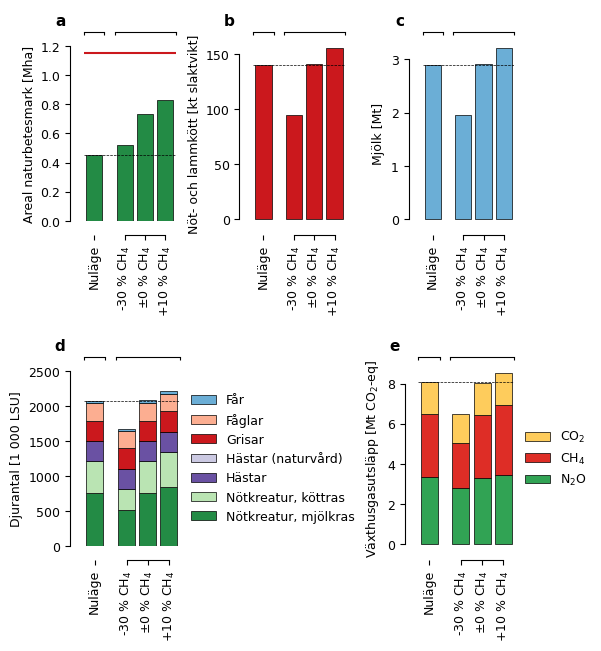

WIN_LAMB


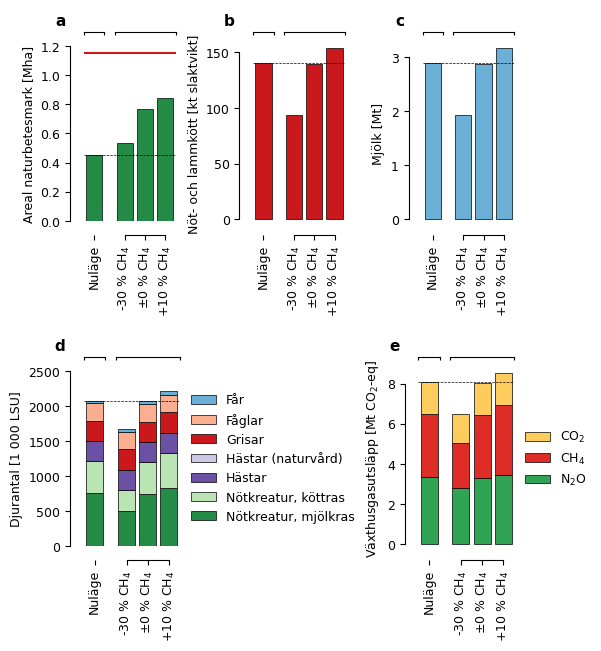

CUL_COWS


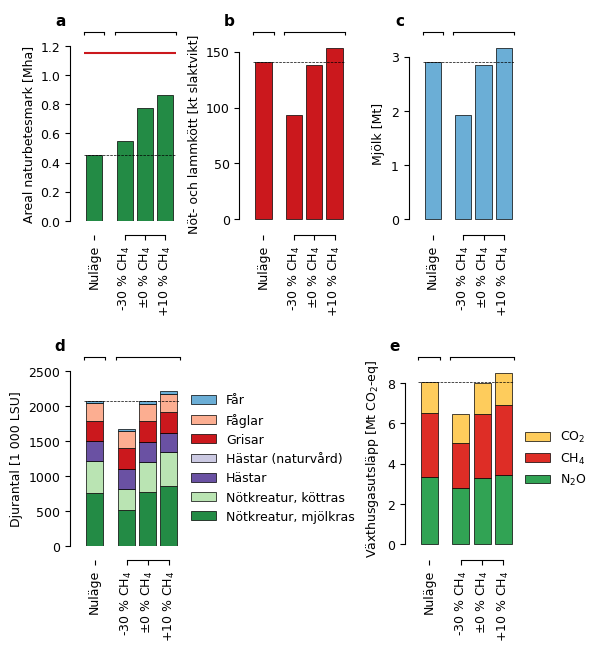

REC_HORSES


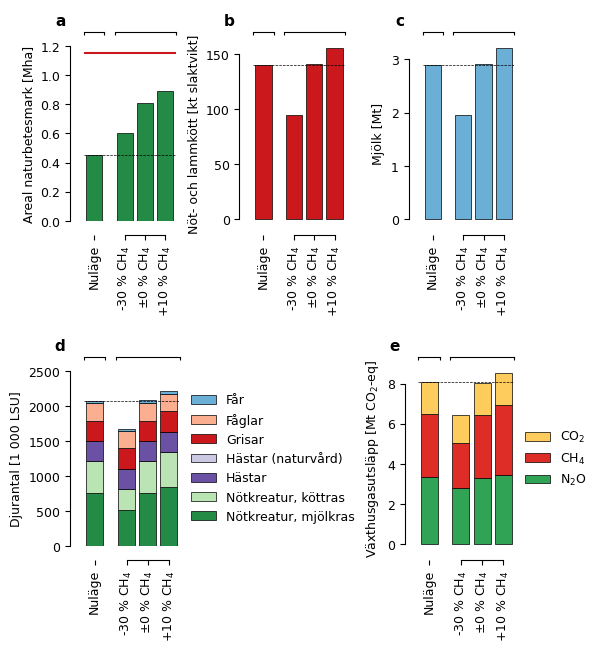

DRY_COWS


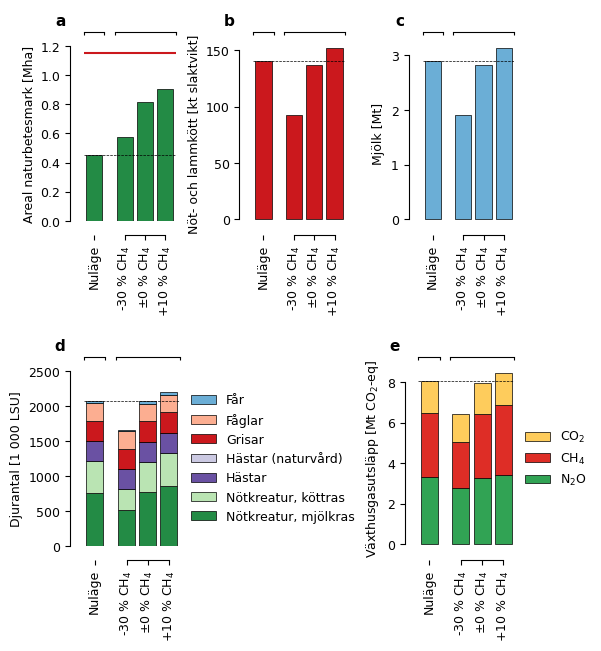

STEERS


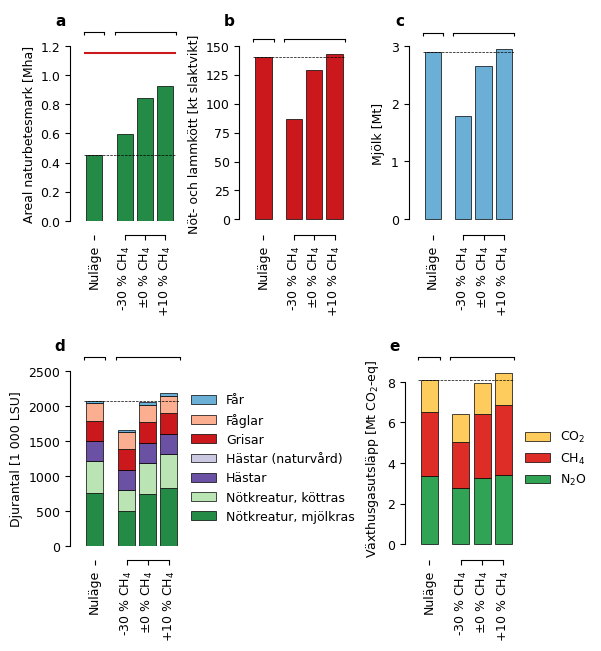

ALL


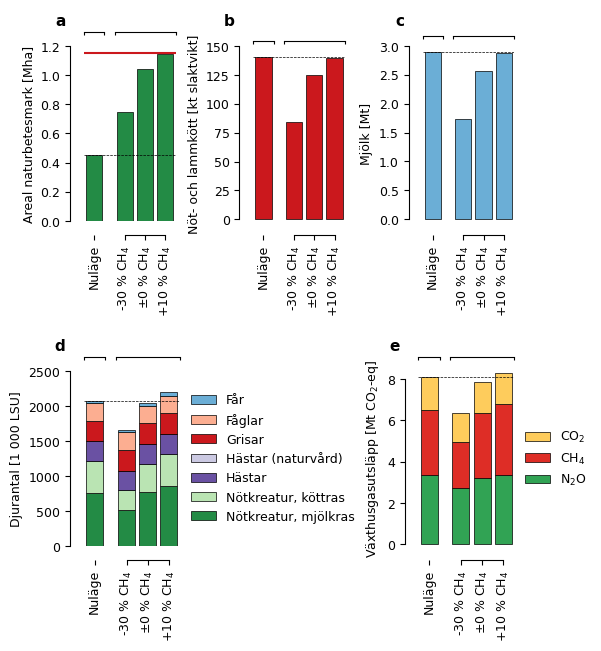

NAT_HORSES


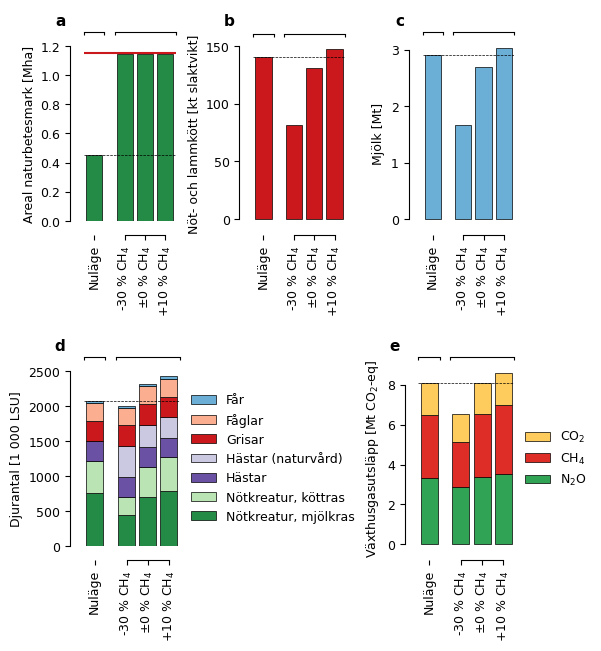

ALL + NAT_HORSES


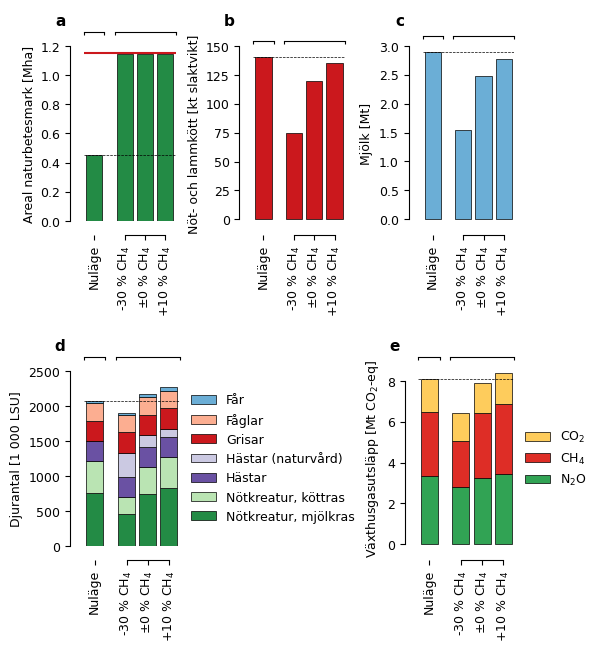

In [150]:
for scn in [s for s in sort if s != 'BL']:
    print(scn)
    fig = plt.figure(figsize = (4.3, 5))
    
    (topfig, bottomfig) = fig.subfigures(2, 1)
    
    top_axs = topfig.subplots(1, 3)
    bottom_axs = bottomfig.subplots(1, 2)
    
    ax = top_axs[0]
    cm.plot.bar(
        sng.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        cmap=ListedColormap(name='X', colors=['#238b45']),
        ylabel='Areal naturbetesmark [Mha]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,1.2)
    )
    ax.axhline(sng_bl, c='black', linewidth=0.5, linestyle='--')
    ax.axhline(sng_max, c='#cb181d', linewidth=1.5, linestyle='-')
    _legend_n(ax)
    _annotate(ax, 'a')
    
    ax = top_axs[1]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'meat'].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#cb181d']),
        ylabel='Nöt- och lammkött [kt slaktvikt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['meat'], c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'b')
    
    ax = top_axs[2]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'milk'].rename(rename_scn_h, level='scn')/1000,
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#6baed6']),
        ylabel='Mjölk [Mt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['milk']/1000, c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'c')
    
    
    ax = bottom_axs[0]
    cm.plot.bar(
        lsu.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        sort_xlabels=False,
        sort_groups=False,
        cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
        ylabel='Djurantal [1 000 LSU]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,2500)
    )
    ax.axhline(lsu_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'd')
    
    ax = bottom_axs[1]
    cm.plot.bar(
        ghg.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
        ylabel='Växthusgasutsläpp [Mt CO$_{2}$-eq]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(ghg_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'e')
    
    
    # Adjust plots
    topfig.subplots_adjust(left=0, right=1, bottom=0.3, top=1, wspace=0.85, hspace=0)
    bottomfig.subplots_adjust(left=0, right=1, bottom=0, top=0.7, wspace=2.5)
    
    plt.show()

## Maps

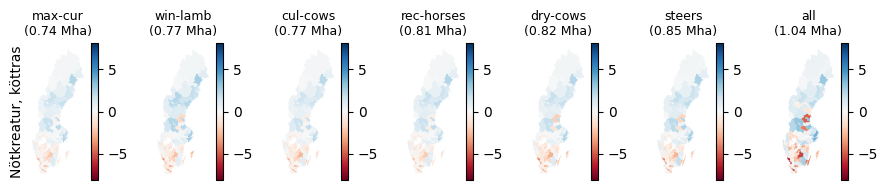

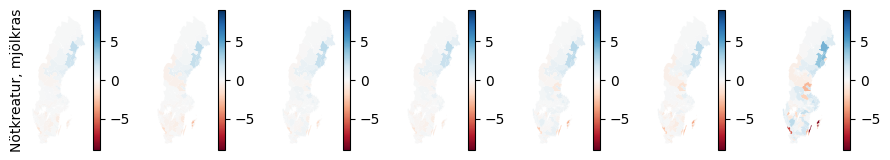

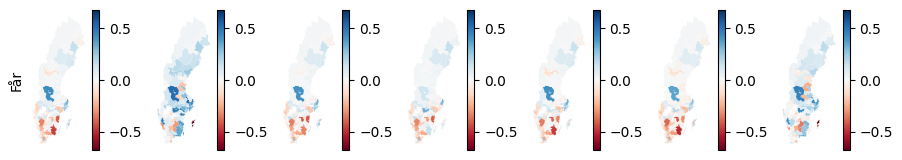

In [102]:
sps = ['Nötkreatur, köttras', 'Nötkreatur, mjölkras', 'Får']
scns = [s for s in sort if s not in ['BL','ALL + NAT_HORSES','NAT_HORSES']]

for sp in sps:
    _lsu_reg = lsu_reg.loc[:,sp]
    _lsu_reg = _lsu_reg.sub(_lsu_reg.loc[('BL', 'Nuläge')], axis=1).loc[scns]
    
    n = len(scns)
    
    fig, axs = plt.subplots(1,n, figsize=(1.3*n,2 if sp == sps[0] else 1.7))
    max = _lsu_reg.abs().max().quantile(0.95)
    
    for scn,ax in zip(scns, axs):
        cm.plot.map_from_series(
            _lsu_reg.loc[(scn, '$\pm$0 % CH$_{4}$')],
            ax = ax,
            cmap = 'RdBu',
            vmax = max,
            vmin = -max
        )
        no_axis(ax)
        if ax == axs[0]:
            ax.set_ylabel(sp)
        if sp == sps[0]:
            ax.set_title(f"{rename_scn(scn)}\n({sng.loc[(scn,'$\pm$0 % CH$_{4}$')]:.2f} Mha)", size=9)
    
    # fig.suptitle(sp, size=11)
    plt.tight_layout()
    plt.show()

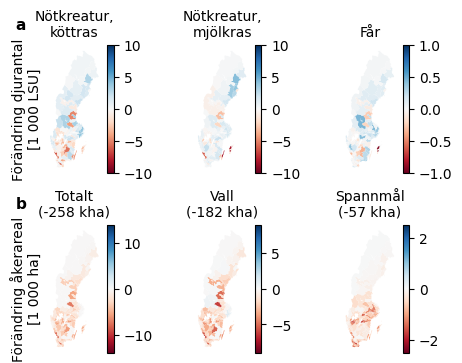

In [124]:
_lsu_reg = (lsu_reg.loc[('ALL', '$\pm$0 % CH$_{4}$')] - lsu_reg.loc[('BL', 'Nuläge')]) 

n = len(sps)
fig, axs = plt.subplots(2,n, figsize=(1.8*n,4), gridspec_kw = {'hspace':0.4})

for sp,ax in zip(sps, axs[0]):
    max = 10 * (0.1 if sp == 'Får' else 1)
    cm.plot.map_from_series(
        _lsu_reg.loc[sp],
        ax = ax,
        cmap = 'RdBu',
        vmin = -max,
        vmax = max
    )
    ax.set_title(sp.replace(', ',',\n'), size=10)
    no_axis(ax)
    if ax == axs[0][0]:
        ax.set_ylabel('Förändring djurantal\n[1 000 LSU]', size=10)

ax = axs[1][0]
d = cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-14,
    vmax=14
)
no_axis(ax)
ax.set_ylabel('Förändring åkerareal\n[1 000 ha]', size=10)
ax.set_title(f"Totalt\n({d.sum():.0f} kha)", size=10)

ax = axs[1][1]
d = ley.loc[('ALL','100')]-ley.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-9,
    vmax=9
)
no_axis(ax)
ax.set_title(f"Vall\n({d.sum():.0f} kha)", size=10)

ax = axs[1][2]
d = cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-2.5,
    vmax=2.5
)
no_axis(ax)
ax.set_title(f"Spannmål\n({d.sum():.0f} kha)", size=10)

_annotate(axs[0][0], 'a  ')
_annotate(axs[1][0], 'b  ')

plt.show()

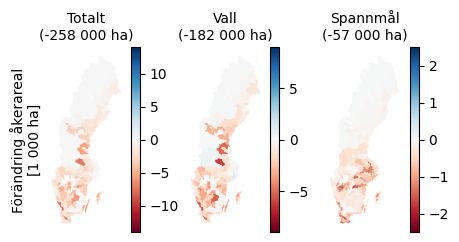

In [100]:
fig, axs = plt.subplots(1,3, figsize=(1.7*3,2.4))

ax = axs[0]
d = cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-14,
    vmax=14
)
no_axis(ax)
ax.set_ylabel('Förändring åkerareal\n[1 000 ha]', size=10)
ax.set_title(f"Totalt\n({d.sum():.0f} 000 ha)", size=10)

ax = axs[1]
d = ley.loc[('ALL','100')]-ley.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-9,
    vmax=9
)
no_axis(ax)
ax.set_title(f"Vall\n({d.sum():.0f} 000 ha)", size=10)

ax = axs[2]
d = cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-2.5,
    vmax=2.5
)
no_axis(ax)
ax.set_title(f"Spannmål\n({d.sum():.0f} 000 ha)", size=10)

plt.show()

In [177]:
# Percentage change in crereals
(cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]).sum() / cereals.loc[('BL','0')].sum() * 100

-6.589556569539458

In [176]:
# Percentage change in ley
(ley.loc[('ALL','100')]-ley.loc[('BL','0')]).sum() / ley.loc[('BL','0')].sum() * 100

-17.370152159641133

In [175]:
# Percentage change in total cropland
(cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]).sum() / cropland_tot.loc[('BL','0')].sum() * 100

-10.910730193033325

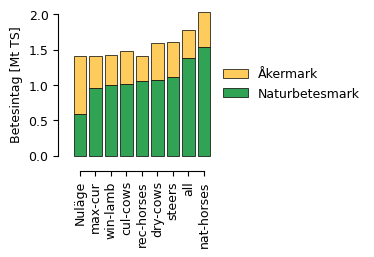

In [93]:
scns = [s for s in sort if s not in ['ALL + NAT_HORSES']]
d = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[(scns,['Nuläge','$\pm$0 % CH$_{4}$']),:]
    .droplevel('year')
    .rename(
        index = rename_scn,
        columns = {'arable':'Åkermark', 'semi-natural grasslands':'Naturbetesmark'}
    )
    .rename({'':'Nuläge'})
)/1_000_000_000

fig,ax = plt.subplots(figsize=(1.8,1.9))
cm.plot.bar(
    d,
    ax = ax,
    sort_categories=True,
    cmap=ListedColormap(name='X', colors=['#31a354', '#fecc5c']),
    ylabel='Betesintag [Mt TS]',
    ylabel_fontsize=9,
    ticklabels_fontsize=9
)
_legend_r(ax)
plt.show()

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

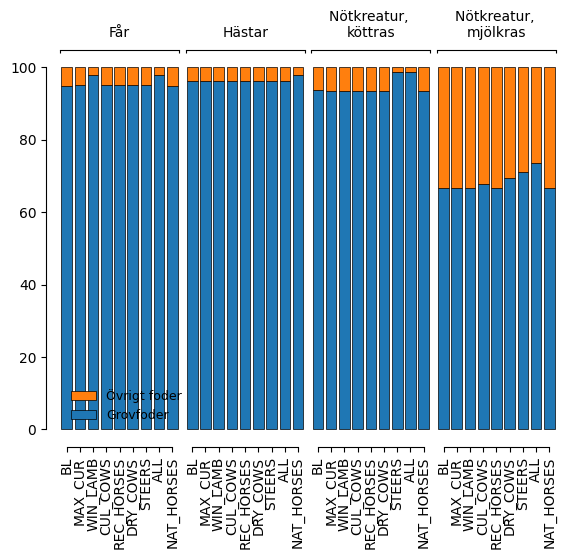

In [83]:
def rename_feeds(x):
    if x in ['ley silage, 1st cut',
             'ley silage, regrowth',
             'other silage',
             'hay',
             'maize silage',
             'grazing']:
        return 'Grovfoder'
    else:
        return 'Övrigt foder'

d = (
    session.get_attr('a','feed.consumption',['species','breed','feed'])
    .rename(columns=rename_feeds, level='feed')
    .rename(rename_years)
    .T.groupby(['species','breed','feed']).sum().T
    .loc[(scns,['Nuläge','$\pm$0 % CH$_{4}$']),:]
    .droplevel('year')
)

d.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}', fe) if sp == 'cattle'
     else (sp, fe)
     for sp,br,fe in d.columns],
    names = ['species','feed']
)

d = d.T.groupby(['species','feed']).sum().T

d = d.T.groupby('species').apply(lambda x: x/x.sum() * 100).droplevel(0).T

d = (
    d
    .rename({
        'cattle, dairy' : 'Nötkreatur, mjölkras',
        'cattle, beef' : 'Nötkreatur, köttras',
        'sheep' : 'Får',
        'horses' : 'Hästar',
        'horses, cons.' : 'Hästar (naturvård)',
        'poultry' : 'Fåglar',
        'pigs' : 'Grisar'
    }, axis=1)
)

d = d.drop(['Grisar','Fåglar'], axis=1, level='species')

d = d.stack('species')

cm.plot.bar(
    d,
    group_levels='species'
)

In [78]:
d

species               Nötkreatur, köttras              Nötkreatur, mjölkras  \
feed                            Grovfoder Övrigt foder            Grovfoder   
scn              year                                                         
BL               0              93.732226     6.267774            66.565588   
MAX_CUR          70             93.389148     6.610852            66.553641   
                 100            93.389148     6.610852            66.533779   
                 110            93.389148     6.610852            66.501696   
STEERS           70             98.698131     1.301869            71.022348   
                 100            98.698131     1.301869            70.971213   
                 110            98.698131     1.301869            70.954112   
REC_HORSES       70             93.389148     6.610852            66.563945   
                 100            93.389148     6.610852            66.533319   
                 110            93.389148     6.610852            66.517221   
WIN_LAMB         70             93.389148     6.610852            66.557669   
                 100            93.389148     6.610852            66.520663   
                 110            93.389148     6.610852            66.514200   
CUL_COWS         70             93.389148     6.610852            67.686437   
                 100            93.389148     6.610852            67.660982   
                 110            93.389148     6.610852            67.637417   
DRY_COWS         70             93.389148     6.610852            69.366167   
                 100            93.389148     6.610852            69.331152   
                 110            93.389148     6.610852            69.317587   
ALL              70             98.698131     1.301869            73.686029   
                 100            98.698131     1.301869            73.635542   
                 110            98.698131     1.301869            73.156874   
ALL + NAT_HORSES 70             98.698131     1.301869            73.659667   
                 100            98.698131     1.301869            73.673717   
                 110            98.698514     1.301486            73.675000   
NAT_HORSES       70             93.389148     6.610852            66.511464   
                 100            93.389148     6.610852            66.524376   
                 110            93.403103     6.596897            66.519732   

species                                Hästar                     Får  \
feed                  Övrigt foder  Grovfoder Övrigt foder  Grovfoder   
scn              year                                                   
BL               0       33.434412  96.075151     3.924849  94.916699   
MAX_CUR          70      33.446359  96.075143     3.924857  94.916699   
                 100     33.466221  96.075151     3.924849  95.024085   
                 110     33.498304  96.075152     3.924848  95.417248   
STEERS           70      28.977652  96.075155     3.924845  94.916699   
                 100     29.028787  96.075159     3.924841  95.024085   
                 110     29.045888  96.075152     3.924848  95.024085   
REC_HORSES       70      33.436055  96.075152     3.924848  94.916699   
                 100     33.466681  96.075155     3.924845  95.024085   
                 110     33.482779  96.075160     3.924840  95.417248   
WIN_LAMB         70      33.442331  96.075141     3.924859  97.836509   
                 100     33.479337  96.075158     3.924842  97.836509   
                 110     33.485800  96.075157     3.924843  97.823812   
CUL_COWS         70      32.313563  96.075140     3.924860  94.916699   
                 100     32.339018  96.075145     3.924855  95.024085   
                 110     32.362583  96.075156     3.924844  95.146008   
DRY_COWS         70      30.633833  96.075139     3.924861  94.916699   
                 100     30.668848  96.075154     3.924846  95.024085   
                 

## Numbers for text

In [30]:
sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
sng2 = sng.drop('BL').unstack()
sng2_bl = sng_bl.unstack()

sng2 = sng2.sub(sng2.loc['MAX_CUR'], axis=1).div(sng2.loc['MAX_CUR'], axis=1) * 100
sng2_bl = sng2_bl.sub(sng2_bl.loc['MAX_CUR'], axis=1)

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_8800\3849719219.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_8800\3849719219.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng2 = sng.drop('BL').unstack()


In [34]:
sng

scn               year           
BL                Nuläge             0.453267
MAX_CUR           -30 % CH$_{4}$     0.523023
                  +/-0 % CH$_{4}$    0.735906
                  +10 % CH$_{4}$     0.827105
STEERS            -30 % CH$_{4}$     0.597237
                  +/-0 % CH$_{4}$    0.845945
                  +10 % CH$_{4}$     0.928504
REC_HORSES        -30 % CH$_{4}$     0.602413
                  +/-0 % CH$_{4}$    0.808990
                  +10 % CH$_{4}$     0.892072
WIN_LAMB          -30 % CH$_{4}$     0.536727
                  +/-0 % CH$_{4}$    0.769248
                  +10 % CH$_{4}$     0.840854
CUL_COWS          -30 % CH$_{4}$     0.551427
                  +/-0 % CH$_{4}$    0.772479
                  +10 % CH$_{4}$     0.866398
DRY_COWS          -30 % CH$_{4}$     0.577285
                  +/-0 % CH$_{4}$    0.818998
                  +10 % CH$_{4}$     0.903784
ALL               -30 % CH$_{4}$     0.748302
                  +/-0 % CH$_{4}$    1.042944


In [31]:
sng_bl

scn               year           
MAX_CUR           -30 % CH$_{4}$      15.389471
                  +/-0 % CH$_{4}$     62.355922
                  +10 % CH$_{4}$      82.476148
STEERS            -30 % CH$_{4}$      31.762550
                  +/-0 % CH$_{4}$     86.632735
                  +10 % CH$_{4}$     104.846772
REC_HORSES        -30 % CH$_{4}$      32.904478
                  +/-0 % CH$_{4}$     78.479614
                  +10 % CH$_{4}$      96.809178
WIN_LAMB          -30 % CH$_{4}$      18.412838
                  +/-0 % CH$_{4}$     69.711813
                  +10 % CH$_{4}$      85.509410
CUL_COWS          -30 % CH$_{4}$      21.655981
                  +/-0 % CH$_{4}$     70.424605
                  +10 % CH$_{4}$      91.145019
DRY_COWS          -30 % CH$_{4}$      27.360732
                  +/-0 % CH$_{4}$     80.687593
                  +10 % CH$_{4}$      99.393030
ALL               -30 % CH$_{4}$      65.090555
                  +/-0 % CH$_{4}$    130.094713
      

In [32]:
sng2

year,-30 % CH$_{4}$,+/-0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,14.189405,14.952835,12.259478
REC_HORSES,15.179034,9.931077,7.854742
WIN_LAMB,2.620142,4.530719,1.662278
CUL_COWS,5.430748,4.969750,4.750687
DRY_COWS,10.374657,11.291039,9.270736
ALL,43.072461,41.722403,38.573935
ALL + NAT_HORSES,119.139908,55.746939,38.573935
NAT_HORSES,118.986951,55.638230,38.477213


In [33]:
sng2_bl

year,-30 % CH$_{4}$,+/-0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,16.373080,24.276812,22.370624
REC_HORSES,17.515007,16.123691,14.333030
WIN_LAMB,3.023368,7.355891,3.033262
CUL_COWS,6.266511,8.068683,8.668871
DRY_COWS,11.971261,18.331671,16.916882
ALL,49.701085,67.738791,70.388231
ALL + NAT_HORSES,137.474909,90.508457,70.388231
NAT_HORSES,137.298413,90.331961,70.211735
